In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.stats import skew, kurtosis, entropy

import wfdb
import neurokit2 as nk

warnings.filterwarnings("ignore")

In [5]:
PROJECT_DIR = Path.cwd()

DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
FEATURE_DIR = DATA_DIR / "features"

RESULTS_DIR = PROJECT_DIR / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"

FEATURE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Correct input file from Notebook 1 / processed records
detection_file_path = PROCESSED_DIR / "ptb_detection_records.csv"

advanced_features_path = FEATURE_DIR / "ptb_detection_advanced_fiducial_features.csv"
advanced_feature_metadata_path = TABLE_DIR / "notebook4B_advanced_fiducial_feature_metadata.json"

print("Project directory:", PROJECT_DIR)
print("Detection records file:", detection_file_path)
print("Detection records file exists:", detection_file_path.exists())
print("Advanced feature output:", advanced_features_path)

if not detection_file_path.exists():
    raise FileNotFoundError("ptb_detection_records.csv not found. Please check data/processed folder.")

Project directory: d:\HUST\ET4248E - Học máy trong y tế\Final Project
Detection records file: d:\HUST\ET4248E - Học máy trong y tế\Final Project\data\processed\ptb_detection_records.csv
Detection records file exists: True
Advanced feature output: d:\HUST\ET4248E - Học máy trong y tế\Final Project\data\features\ptb_detection_advanced_fiducial_features.csv


In [6]:
PURPLE_MAIN = "#C599B6"
PURPLE_DARK = "#8A5A78"
PURPLE_LIGHT = "#E8D3DF"
RED_SOFT = "#C44E52"
GRAY = "#6B6B6B"

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

In [7]:
detection_df = pd.read_csv(detection_file_path)

print("Detection dataframe shape:", detection_df.shape)
display(detection_df.head())

required_cols = [
    "patient_id",
    "record_id",
    "record_path",
    "reason_for_admission",
    "mi_detected"
]

missing_required_cols = [
    col for col in required_cols
    if col not in detection_df.columns
]

if len(missing_required_cols) > 0:
    raise ValueError(f"Missing required columns: {missing_required_cols}")

print("\nClass distribution:")
display(detection_df["mi_detected"].value_counts())

print("\nColumns:")
print(detection_df.columns.tolist())

Detection dataframe shape: (448, 15)


,patient_id,record_id,record_path,age,sex,reason_for_admission,raw_localization,fs,n_sig,sig_len,duration_sec,comments_text,mi_detected,healthy_control,broad_group
0,patient001,s0010_re,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,81.0,female,Myocardial infarction,inferior,1000,15,38400,38.4,age: 81 | sex: female | ECG date: 01/10/1990 |...,1,0,Myocardial Infarction
1,patient001,s0014lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,81.0,female,Myocardial infarction,inferior,1000,15,115200,115.2,age: 81 | sex: female | ECG date: 17/10/1990 |...,1,0,Myocardial Infarction
2,patient001,s0016lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,81.0,female,Myocardial infarction,inferior,1000,15,115200,115.2,age: 81 | sex: female | ECG date: 18/10/1990 |...,1,0,Myocardial Infarction
3,patient002,s0015lre,ptb-diagnostic-ecg-database-1.0.0\patient002\s...,58.0,female,Myocardial infarction,anterior,1000,15,115200,115.2,age: 58 | sex: female | ECG date: 17/10/1990 |...,1,0,Myocardial Infarction
4,patient003,s0017lre,ptb-diagnostic-ecg-database-1.0.0\patient003\s...,63.0,male,Myocardial infarction,infero-lateral+infero-postero-lateral+posterio...,1000,15,115200,115.2,age: 63 | sex: male | ECG date: 18/10/1990 | D...,1,0,Myocardial Infarction



Class distribution:


mi_detected
1    368
0     80
Name: count, dtype: int64


Columns:
['patient_id', 'record_id', 'record_path', 'age', 'sex', 'reason_for_admission', 'raw_localization', 'fs', 'n_sig', 'sig_len', 'duration_sec', 'comments_text', 'mi_detected', 'healthy_control', 'broad_group']


In [8]:
LEAD_NAMES = [
    "i", "ii", "iii",
    "avr", "avl", "avf",
    "v1", "v2", "v3", "v4", "v5", "v6"
]

LEAD_DISPLAY_NAMES = {
    "i": "I",
    "ii": "II",
    "iii": "III",
    "avr": "aVR",
    "avl": "aVL",
    "avf": "aVF",
    "v1": "V1",
    "v2": "V2",
    "v3": "V3",
    "v4": "V4",
    "v5": "V5",
    "v6": "V6"
}

LEAD_GROUPS = {
    "limb": ["i", "ii", "iii", "avr", "avl", "avf"],
    "chest": ["v1", "v2", "v3", "v4", "v5", "v6"],
    "inferior": ["ii", "iii", "avf"],
    "anterior": ["v1", "v2", "v3", "v4"],
    "lateral": ["i", "avl", "v5", "v6"]
}

print("Lead names:")
print(LEAD_NAMES)

print("\nLead groups:")
for group, leads in LEAD_GROUPS.items():
    print(group, ":", [LEAD_DISPLAY_NAMES[l] for l in leads])

Lead names:
['i', 'ii', 'iii', 'avr', 'avl', 'avf', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6']

Lead groups:
limb : ['I', 'II', 'III', 'aVR', 'aVL', 'aVF']
chest : ['V1', 'V2', 'V3', 'V4', 'V5', 'V6']
inferior : ['II', 'III', 'aVF']
anterior : ['V1', 'V2', 'V3', 'V4']
lateral : ['I', 'aVL', 'V5', 'V6']


In [10]:
def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq

    b, a = butter(order, [low, high], btype="band")
    filtered = filtfilt(b, a, signal, axis=0)

    return filtered


def zscore_normalize(signal, eps=1e-8):
    mean = np.mean(signal, axis=0)
    std = np.std(signal, axis=0)

    normalized = (signal - mean) / (std + eps)

    return normalized


def read_12lead_record(record_path):
    """
    Read one PTB ECG record and select standard 12 leads.

    The record_path in ptb_detection_records.csv is relative, for example:
    ptb-diagnostic-ecg-database-1.0.0/patient001/s0010_re

    This function automatically joins it with PROJECT_DIR.
    """
    record_path = Path(record_path)

    if not record_path.is_absolute():
        record_path = PROJECT_DIR / record_path

    # WFDB expects path without .hea/.dat suffix
    if record_path.suffix in [".hea", ".dat"]:
        record_base = record_path.with_suffix("")
    else:
        record_base = record_path

    record = wfdb.rdrecord(str(record_base))

    signal = record.p_signal
    fs = int(record.fs)
    lead_names_raw = [name.lower() for name in record.sig_name]

    lead_indices = []

    for lead in LEAD_NAMES:
        if lead not in lead_names_raw:
            raise ValueError(f"Lead {lead} not found in record {record_base}")
        lead_indices.append(lead_names_raw.index(lead))

    signal_12 = signal[:, lead_indices]

    return signal_12, fs

In [11]:
# Cell 7: QRS peak detection
def detect_qrs_peaks_neurokit_best_direction(signal_1d, fs):
    """
    Detect QRS peaks using NeuroKit2.

    The function tests both original and inverted signal directions.
    The selected direction is the one with plausible HR and more stable RR intervals.
    """
    candidates = []

    for direction_name, sig in [
        ("original", signal_1d),
        ("inverted", -signal_1d)
    ]:
        try:
            _, info = nk.ecg_peaks(
                sig,
                sampling_rate=fs,
                method="neurokit",
                correct_artifacts=True
            )

            peaks = np.array(info["ECG_R_Peaks"], dtype=int)

            if len(peaks) < 2:
                continue

            rr = np.diff(peaks) / fs
            hr_median = 60.0 / np.median(rr)
            rr_std = np.std(rr)

            plausible_hr = 40 <= hr_median <= 180

            candidates.append({
                "direction": direction_name,
                "peaks": peaks,
                "n_peaks": len(peaks),
                "hr_median": hr_median,
                "rr_std": rr_std,
                "plausible_hr": plausible_hr
            })

        except Exception:
            continue

    if len(candidates) == 0:
        return {
            "direction": "failed",
            "peaks": np.array([], dtype=int),
            "hr_median": np.nan,
            "rr_std": np.nan
        }

    plausible_candidates = [
        c for c in candidates
        if c["plausible_hr"]
    ]

    if len(plausible_candidates) > 0:
        best = sorted(
            plausible_candidates,
            key=lambda x: (x["rr_std"], -x["n_peaks"])
        )[0]
    else:
        best = sorted(
            candidates,
            key=lambda x: (abs(x["hr_median"] - 75), x["rr_std"])
        )[0]

    return {
        "direction": best["direction"],
        "peaks": best["peaks"],
        "hr_median": best["hr_median"],
        "rr_std": best["rr_std"]
    }

In [12]:
# Beat segmentation around QRS peak
def segment_beats(signal_12, qrs_peaks, fs, pre_qrs_sec=0.25, post_qrs_sec=0.45):
    """
    Segment beats around detected QRS peaks.

    Window:
    - 0.25 s before QRS peak
    - 0.45 s after QRS peak
    """
    pre = int(pre_qrs_sec * fs)
    post = int(post_qrs_sec * fs)

    beats = []
    valid_peaks = []

    for peak in qrs_peaks:
        start = peak - pre
        end = peak + post

        if start < 0 or end > signal_12.shape[0]:
            continue

        beat = signal_12[start:end, :]
        beats.append(beat)
        valid_peaks.append(peak)

    if len(beats) == 0:
        return np.empty((0, pre + post, signal_12.shape[1])), np.array([], dtype=int)

    return np.stack(beats, axis=0), np.array(valid_peaks, dtype=int)

In [13]:
# Advanced fiducial-inspired windows
ADVANCED_WINDOWS = {
    "baseline": (-0.22, -0.14),

    "q_search": (-0.06, -0.005),
    "r_search": (-0.03, 0.03),
    "s_search": (0.005, 0.08),

    "qrs_region": (-0.06, 0.08),

    "st_j40": (0.115, 0.125),
    "st_j60": (0.135, 0.145),
    "st_j80": (0.155, 0.165),

    "st_segment": (0.08, 0.16),
    "early_st": (0.08, 0.12),
    "late_st": (0.12, 0.16),

    "t_region": (0.12, 0.38),
    "early_t": (0.12, 0.22),
    "late_t": (0.22, 0.38)
}

print("Advanced fiducial-inspired windows:")
for key, value in ADVANCED_WINDOWS.items():
    print(key, ":", value)

Advanced fiducial-inspired windows:
baseline : (-0.22, -0.14)
q_search : (-0.06, -0.005)
r_search : (-0.03, 0.03)
s_search : (0.005, 0.08)
qrs_region : (-0.06, 0.08)
st_j40 : (0.115, 0.125)
st_j60 : (0.135, 0.145)
st_j80 : (0.155, 0.165)
st_segment : (0.08, 0.16)
early_st : (0.08, 0.12)
late_st : (0.12, 0.16)
t_region : (0.12, 0.38)
early_t : (0.12, 0.22)
late_t : (0.22, 0.38)


In [27]:
# Cell 10 — Utility functions
def get_window_indices(time_axis, start_sec, end_sec):
    return np.where((time_axis >= start_sec) & (time_axis <= end_sec))[0]


def safe_mean(x):
    if len(x) == 0:
        return np.nan
    return float(np.mean(x))


def safe_median(x):
    if len(x) == 0:
        return np.nan
    return float(np.median(x))


def safe_std(x):
    if len(x) == 0:
        return np.nan
    return float(np.std(x))


def safe_min(x):
    if len(x) == 0:
        return np.nan
    return float(np.min(x))


def safe_max(x):
    if len(x) == 0:
        return np.nan
    return float(np.max(x))


def safe_area(x, dt):
    if len(x) == 0:
        return np.nan
    
    return float(np.trapezoid(x, dx=dt))


def safe_ratio(num, den, eps=1e-8):
    if pd.isna(num) or pd.isna(den):
        return np.nan
    return float(num / (den + eps))

In [41]:
# Cell 11
def extract_advanced_features_from_lead(beats_lead, time_axis, fs):
    """
    Extract advanced fiducial-inspired morphology features from one ECG lead.

    beats_lead shape:
    (n_beats, n_samples)

    Important:
    These features are fiducial-inspired morphology proxies.
    They are not expert-annotated clinical fiducial points.

    The QRS peak is defined as the dominant absolute deflection within
    a short QRS-centered search window. Therefore, qrs_peak_amp can be
    positive or negative depending on lead polarity and ECG morphology.
    """

    dt = 1.0 / fs

    feature_values = {
        # Q/S proxy features
        "q_amp": [],
        "s_amp": [],
        "q_time": [],
        "s_time": [],

        # Dominant QRS peak features
        "qrs_peak_amp": [],
        "qrs_peak_abs_amp": [],
        "qrs_peak_time": [],
        "qrs_max_amp": [],
        "qrs_min_amp": [],
        "qrs_ptp_amp": [],
        "qrs_area": [],
        "qrs_abs_area": [],
        "qrs_duration_proxy": [],

        # ST features
        "st_level_j40": [],
        "st_level_j60": [],
        "st_level_j80": [],
        "st_slope": [],
        "st_area": [],

        # T-wave features
        "t_max_amp": [],
        "t_min_amp": [],
        "t_amp": [],
        "t_abs_amp": [],
        "t_area": [],
        "t_abs_area": [],
        "t_polarity": [],
        "t_peak_time": [],

        # Ratio features
        "qrs_s_ratio": [],
        "q_qrs_ratio": [],
        "s_qrs_ratio": [],
        "t_qrs_peak_ratio": [],
        "st_qrs_peak_ratio": [],
        "t_qrs_ptp_ratio": [],

        # Time proxy features
        "qt_proxy": [],
        "qrs_to_t_peak": []
    }

    idx_baseline = get_window_indices(time_axis, *ADVANCED_WINDOWS["baseline"])
    idx_q = get_window_indices(time_axis, *ADVANCED_WINDOWS["q_search"])
    idx_r = get_window_indices(time_axis, *ADVANCED_WINDOWS["r_search"])
    idx_s = get_window_indices(time_axis, *ADVANCED_WINDOWS["s_search"])
    idx_qrs = get_window_indices(time_axis, *ADVANCED_WINDOWS["qrs_region"])
    idx_st40 = get_window_indices(time_axis, *ADVANCED_WINDOWS["st_j40"])
    idx_st60 = get_window_indices(time_axis, *ADVANCED_WINDOWS["st_j60"])
    idx_st80 = get_window_indices(time_axis, *ADVANCED_WINDOWS["st_j80"])
    idx_st = get_window_indices(time_axis, *ADVANCED_WINDOWS["st_segment"])
    idx_early_st = get_window_indices(time_axis, *ADVANCED_WINDOWS["early_st"])
    idx_late_st = get_window_indices(time_axis, *ADVANCED_WINDOWS["late_st"])
    idx_t = get_window_indices(time_axis, *ADVANCED_WINDOWS["t_region"])

    for beat in beats_lead:
        baseline = safe_mean(beat[idx_baseline])
        beat_corr = beat - baseline

        q_region = beat_corr[idx_q]
        s_region = beat_corr[idx_s]
        qrs_peak_region = beat_corr[idx_r]
        qrs_region = beat_corr[idx_qrs]

        # Q proxy: minimum before QRS peak
        if len(q_region) > 0:
            q_local = int(np.argmin(q_region))
            q_amp = float(q_region[q_local])
            q_time = float(time_axis[idx_q[q_local]])
        else:
            q_amp = np.nan
            q_time = np.nan

        # S proxy: minimum after QRS peak
        if len(s_region) > 0:
            s_local = int(np.argmin(s_region))
            s_amp = float(s_region[s_local])
            s_time = float(time_axis[idx_s[s_local]])
        else:
            s_amp = np.nan
            s_time = np.nan

        # Dominant QRS peak:
        # strongest absolute deflection in the QRS-centered search window
        if len(qrs_peak_region) > 0:
            peak_local = int(np.argmax(np.abs(qrs_peak_region)))
            qrs_peak_amp = float(qrs_peak_region[peak_local])
            qrs_peak_abs_amp = abs(qrs_peak_amp)
            qrs_peak_time = float(time_axis[idx_r[peak_local]])
        else:
            qrs_peak_amp = np.nan
            qrs_peak_abs_amp = np.nan
            qrs_peak_time = np.nan

        # QRS morphology from wider QRS window
        qrs_max_amp = safe_max(qrs_region)
        qrs_min_amp = safe_min(qrs_region)
        qrs_ptp = qrs_max_amp - qrs_min_amp
        qrs_area = safe_area(qrs_region, dt)
        qrs_abs_area = safe_area(np.abs(qrs_region), dt)

        if not pd.isna(q_time) and not pd.isna(s_time):
            qrs_duration = s_time - q_time
        else:
            qrs_duration = np.nan

        # ST level and slope
        st40 = safe_mean(beat_corr[idx_st40])
        st60 = safe_mean(beat_corr[idx_st60])
        st80 = safe_mean(beat_corr[idx_st80])

        early_st = safe_mean(beat_corr[idx_early_st])
        late_st = safe_mean(beat_corr[idx_late_st])
        st_slope = safe_ratio(late_st - early_st, 0.04)

        st_area = safe_area(beat_corr[idx_st], dt)

        # T-wave features
        t_region = beat_corr[idx_t]

        if len(t_region) > 0:
            t_max_local = int(np.argmax(t_region))
            t_min_local = int(np.argmin(t_region))

            t_max_amp = float(t_region[t_max_local])
            t_min_amp = float(t_region[t_min_local])

            if abs(t_max_amp) >= abs(t_min_amp):
                t_amp = t_max_amp
                t_peak_time = float(time_axis[idx_t[t_max_local]])
            else:
                t_amp = t_min_amp
                t_peak_time = float(time_axis[idx_t[t_min_local]])

            t_abs_amp = abs(t_amp)
            t_area = safe_area(t_region, dt)
            t_abs_area = safe_area(np.abs(t_region), dt)

            if t_amp > 0:
                t_polarity = 1
            elif t_amp < 0:
                t_polarity = -1
            else:
                t_polarity = 0
        else:
            t_max_amp = np.nan
            t_min_amp = np.nan
            t_amp = np.nan
            t_abs_amp = np.nan
            t_area = np.nan
            t_abs_area = np.nan
            t_polarity = np.nan
            t_peak_time = np.nan

        # Ratio features
        qrs_s_ratio = safe_ratio(qrs_peak_amp, abs(s_amp))
        q_qrs_ratio = safe_ratio(abs(q_amp), qrs_peak_abs_amp)
        s_qrs_ratio = safe_ratio(abs(s_amp), qrs_peak_abs_amp)
        t_qrs_peak_ratio = safe_ratio(t_amp, qrs_peak_abs_amp)
        st_qrs_peak_ratio = safe_ratio(st60, qrs_peak_abs_amp)
        t_qrs_ptp_ratio = safe_ratio(t_abs_amp, qrs_ptp)

        # Time proxy features
        if not pd.isna(q_time) and not pd.isna(t_peak_time):
            qt_proxy = t_peak_time - q_time
        else:
            qt_proxy = np.nan

        if not pd.isna(qrs_peak_time) and not pd.isna(t_peak_time):
            qrs_to_t_peak = t_peak_time - qrs_peak_time
        else:
            qrs_to_t_peak = np.nan

        feature_values["q_amp"].append(q_amp)
        feature_values["s_amp"].append(s_amp)
        feature_values["q_time"].append(q_time)
        feature_values["s_time"].append(s_time)

        feature_values["qrs_peak_amp"].append(qrs_peak_amp)
        feature_values["qrs_peak_abs_amp"].append(qrs_peak_abs_amp)
        feature_values["qrs_peak_time"].append(qrs_peak_time)
        feature_values["qrs_max_amp"].append(qrs_max_amp)
        feature_values["qrs_min_amp"].append(qrs_min_amp)
        feature_values["qrs_ptp_amp"].append(qrs_ptp)
        feature_values["qrs_area"].append(qrs_area)
        feature_values["qrs_abs_area"].append(qrs_abs_area)
        feature_values["qrs_duration_proxy"].append(qrs_duration)

        feature_values["st_level_j40"].append(st40)
        feature_values["st_level_j60"].append(st60)
        feature_values["st_level_j80"].append(st80)
        feature_values["st_slope"].append(st_slope)
        feature_values["st_area"].append(st_area)

        feature_values["t_max_amp"].append(t_max_amp)
        feature_values["t_min_amp"].append(t_min_amp)
        feature_values["t_amp"].append(t_amp)
        feature_values["t_abs_amp"].append(t_abs_amp)
        feature_values["t_area"].append(t_area)
        feature_values["t_abs_area"].append(t_abs_area)
        feature_values["t_polarity"].append(t_polarity)
        feature_values["t_peak_time"].append(t_peak_time)

        feature_values["qrs_s_ratio"].append(qrs_s_ratio)
        feature_values["q_qrs_ratio"].append(q_qrs_ratio)
        feature_values["s_qrs_ratio"].append(s_qrs_ratio)
        feature_values["t_qrs_peak_ratio"].append(t_qrs_peak_ratio)
        feature_values["st_qrs_peak_ratio"].append(st_qrs_peak_ratio)
        feature_values["t_qrs_ptp_ratio"].append(t_qrs_ptp_ratio)

        feature_values["qt_proxy"].append(qt_proxy)
        feature_values["qrs_to_t_peak"].append(qrs_to_t_peak)

    output = {}

    for feature_name, values in feature_values.items():
        values = np.array(values, dtype=float)
        values = values[np.isfinite(values)]

        if len(values) == 0:
            output[f"{feature_name}_mean"] = np.nan
            output[f"{feature_name}_median"] = np.nan
            output[f"{feature_name}_std"] = np.nan
            output[f"{feature_name}_min"] = np.nan
            output[f"{feature_name}_max"] = np.nan
            output[f"{feature_name}_iqr"] = np.nan
        else:
            output[f"{feature_name}_mean"] = float(np.mean(values))
            output[f"{feature_name}_median"] = float(np.median(values))
            output[f"{feature_name}_std"] = float(np.std(values))
            output[f"{feature_name}_min"] = float(np.min(values))
            output[f"{feature_name}_max"] = float(np.max(values))
            output[f"{feature_name}_iqr"] = float(
                np.percentile(values, 75) - np.percentile(values, 25)
            )

    return output

In [47]:
def extract_advanced_features_from_record(row):
    features = {}

    features["patient_id"] = row["patient_id"]
    features["record_id"] = row["record_id"]
    features["record_path"] = row["record_path"]
    features["reason_for_admission"] = row["reason_for_admission"]
    features["mi_detected"] = int(row["mi_detected"])

    if "healthy_control" in row.index:
        features["healthy_control"] = int(row["healthy_control"])

    try:
        signal_12_raw, fs = read_12lead_record(row["record_path"])

        signal_12_filtered = bandpass_filter(signal_12_raw, fs)
        signal_12_norm = zscore_normalize(signal_12_filtered)

        lead_ii_idx = LEAD_NAMES.index("ii")
        lead_ii_for_detection = signal_12_filtered[:, lead_ii_idx]

        qrs_info = detect_qrs_peaks_neurokit_best_direction(
            lead_ii_for_detection,
            fs
        )

        qrs_peaks = qrs_info["peaks"]

        beats, valid_peaks = segment_beats(
            signal_12_norm,
            qrs_peaks,
            fs,
            pre_qrs_sec=0.25,
            post_qrs_sec=0.45
        )

        if beats.shape[0] == 0:
            raise ValueError("No valid beats segmented.")

        features["extraction_status"] = "success"
        features["error_message"] = ""
        features["fs"] = fs
        features["duration_sec"] = signal_12_raw.shape[0] / fs
        features["n_samples"] = signal_12_raw.shape[0]
        features["n_detected_qrs_peaks"] = len(qrs_peaks)
        features["n_valid_beats"] = beats.shape[0]
        features["qrs_detection_direction"] = qrs_info["direction"]
        features["rhythm_hr_median"] = qrs_info["hr_median"]
        features["rhythm_rr_std"] = qrs_info["rr_std"]

        time_axis = np.arange(beats.shape[1]) / fs - 0.25

        for lead_idx, lead in enumerate(LEAD_NAMES):
            beats_lead = beats[:, :, lead_idx]

            lead_features = extract_advanced_features_from_lead(
                beats_lead,
                time_axis,
                fs
            )

            for key, value in lead_features.items():
                features[f"{lead}_adv_{key}"] = value

        # Group-level summaries
        group_feature_names = [
            "st_level_j60_mean",
         "st_level_j80_mean",
         "t_amp_mean",
         "t_polarity_mean",
         "q_amp_mean",
         "qrs_peak_amp_mean",
         "qrs_peak_abs_amp_mean",
         "qrs_ptp_amp_mean",
         "qrs_s_ratio_mean",
         "t_qrs_peak_ratio_mean"
            ]

        for group_name, group_leads in LEAD_GROUPS.items():
            for feat_name in group_feature_names:
                values = []

                for lead in group_leads:
                    col = f"{lead}_adv_{feat_name}"
                    if col in features and np.isfinite(features[col]):
                        values.append(features[col])

                if len(values) == 0:
                    features[f"{group_name}_group_adv_{feat_name}_mean"] = np.nan
                    features[f"{group_name}_group_adv_{feat_name}_std"] = np.nan
                else:
                    features[f"{group_name}_group_adv_{feat_name}_mean"] = float(np.mean(values))
                    features[f"{group_name}_group_adv_{feat_name}_std"] = float(np.std(values))

        # Clinically inspired contrasts
        def group_mean(group, feat):
            col = f"{group}_group_adv_{feat}_mean"
            return features.get(col, np.nan)

        contrast_features = [
            "st_level_j60_mean",
            "st_level_j80_mean",
            "t_amp_mean",
            "q_amp_mean",
            "qrs_ptp_amp_mean"
        ]

        for feat in contrast_features:
            features[f"contrast_inferior_minus_anterior_adv_{feat}"] = (
                group_mean("inferior", feat) - group_mean("anterior", feat)
            )

            features[f"contrast_lateral_minus_anterior_adv_{feat}"] = (
                group_mean("lateral", feat) - group_mean("anterior", feat)
            )

            features[f"contrast_chest_minus_limb_adv_{feat}"] = (
                group_mean("chest", feat) - group_mean("limb", feat)
            )

    except Exception as e:
        features["extraction_status"] = "failed"
        features["error_message"] = str(e)

    return features

In [48]:
# Test one record
example_row = detection_df.iloc[0]

print("Example record:")
display(example_row[["patient_id", "record_id", "reason_for_admission", "mi_detected", "record_path"]])

example_features = extract_advanced_features_from_record(example_row)

print("Extraction status:", example_features["extraction_status"])
print("Error message:", example_features["error_message"])
print("Number of extracted fields:", len(example_features))

selected_keys = [
    "patient_id",
    "record_id",
    "mi_detected",
    "n_detected_qrs_peaks",
    "n_valid_beats",
    "rhythm_hr_median",
    "qrs_detection_direction",

    "ii_adv_q_amp_mean",
    "ii_adv_s_amp_mean",
    "ii_adv_qrs_peak_amp_mean",
    "ii_adv_qrs_peak_abs_amp_mean",
    "ii_adv_qrs_max_amp_mean",
    "ii_adv_qrs_min_amp_mean",
    "ii_adv_qrs_ptp_amp_mean",
    "ii_adv_st_level_j60_mean",
    "ii_adv_st_level_j80_mean",
    "ii_adv_t_amp_mean",
    "ii_adv_t_polarity_mean",
    "ii_adv_qrs_s_ratio_mean",
    "ii_adv_t_qrs_peak_ratio_mean",

    "inferior_group_adv_st_level_j60_mean_mean",
    "contrast_inferior_minus_anterior_adv_st_level_j60_mean"
]

for key in selected_keys:
    print(key, ":", example_features.get(key, "not found"))

Example record:


patient_id                                                     patient001
record_id                                                        s0010_re
reason_for_admission                                Myocardial infarction
mi_detected                                                             1
record_path             ptb-diagnostic-ecg-database-1.0.0\patient001\s...
Name: 0, dtype: object

Extraction status: success
Error message: 
Number of extracted fields: 2579
patient_id : patient001
record_id : s0010_re
mi_detected : 1
n_detected_qrs_peaks : 52
n_valid_beats : 51
rhythm_hr_median : 81.74386920980926
qrs_detection_direction : original
ii_adv_q_amp_mean : -3.0666789866447046
ii_adv_s_amp_mean : -4.472116978338431
ii_adv_qrs_peak_amp_mean : -4.472116978338431
ii_adv_qrs_peak_abs_amp_mean : 4.472116978338431
ii_adv_qrs_max_amp_mean : -0.5920219304072352
ii_adv_qrs_min_amp_mean : -4.472116978338431
ii_adv_qrs_ptp_amp_mean : 3.880095047931197
ii_adv_st_level_j60_mean : -0.44505797865387114
ii_adv_st_level_j80_mean : -0.5612605508159888
ii_adv_t_amp_mean : -2.475962204808629
ii_adv_t_polarity_mean : -1.0
ii_adv_qrs_s_ratio_mean : -0.9999999977603963
ii_adv_t_qrs_peak_ratio_mean : -0.5538917420850529
inferior_group_adv_st_level_j60_mean_mean : -0.12051266668870853
contrast_inferior_minus_anterior_adv_st_level_j60_mean : 0.4517332204887631


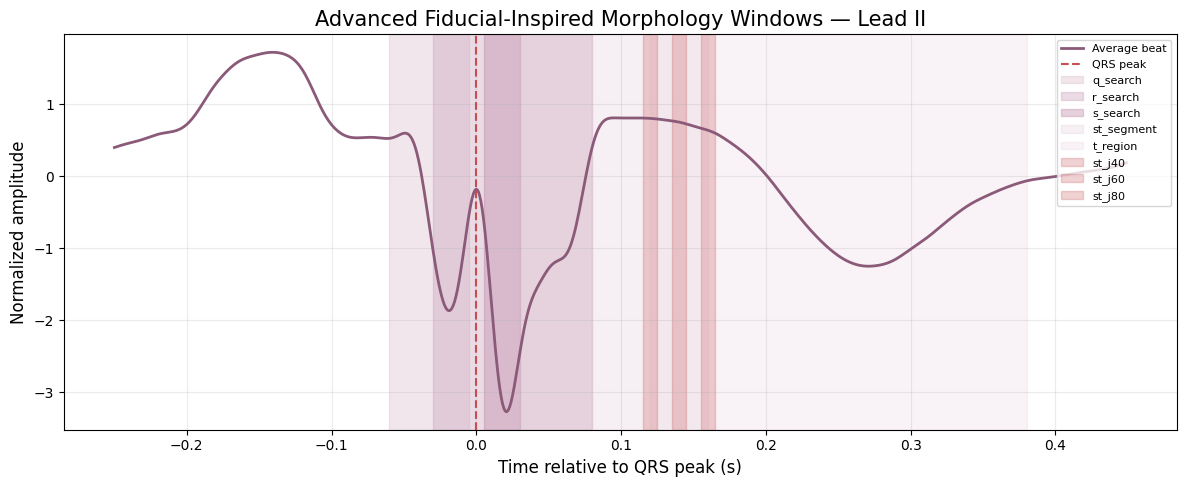

Saved figure: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook4B_advanced_fiducial_windows_example.png


In [49]:
# Cell 14 — Visual check advanced windows
def plot_advanced_windows_for_record(row, lead="ii"):
    signal_12_raw, fs = read_12lead_record(row["record_path"])

    signal_12_filtered = bandpass_filter(signal_12_raw, fs)
    signal_12_norm = zscore_normalize(signal_12_filtered)

    lead_ii_idx = LEAD_NAMES.index("ii")

    qrs_info = detect_qrs_peaks_neurokit_best_direction(
        signal_12_filtered[:, lead_ii_idx],
        fs
    )

    beats, valid_peaks = segment_beats(
        signal_12_norm,
        qrs_info["peaks"],
        fs,
        pre_qrs_sec=0.25,
        post_qrs_sec=0.45
    )

    if beats.shape[0] == 0:
        raise ValueError("No valid beats for plotting.")

    lead_idx = LEAD_NAMES.index(lead)
    avg_beat = np.mean(beats[:, :, lead_idx], axis=0)
    time_axis = np.arange(beats.shape[1]) / fs - 0.25

    plt.figure(figsize=(12, 5))

    plt.plot(
        time_axis,
        avg_beat,
        color=PURPLE_DARK,
        linewidth=2,
        label="Average beat"
    )

    plt.axvline(
        0,
        color=RED_SOFT,
        linestyle="--",
        label="QRS peak"
    )

    window_colors = {
        "q_search": "#D9B8C9",
        "r_search": "#C599B6",
        "s_search": "#B77FA0",
        "st_segment": "#E8D3DF",
        "t_region": "#F0DCE7"
    }

    for name, color in window_colors.items():
        start, end = ADVANCED_WINDOWS[name]
        plt.axvspan(
            start,
            end,
            color=color,
            alpha=0.35,
            label=name
        )

    for st_name in ["st_j40", "st_j60", "st_j80"]:
        start, end = ADVANCED_WINDOWS[st_name]
        plt.axvspan(
            start,
            end,
            color=RED_SOFT,
            alpha=0.25,
            label=st_name
        )

    plt.title(f"Advanced Fiducial-Inspired Morphology Windows — Lead {LEAD_DISPLAY_NAMES[lead]}")
    plt.xlabel("Time relative to QRS peak (s)")
    plt.ylabel("Normalized amplitude")
    plt.legend(loc="upper right", fontsize=8)
    plt.grid(alpha=0.25)
    plt.tight_layout()

    fig_path = FIGURE_DIR / "notebook4B_advanced_fiducial_windows_example.png"
    plt.savefig(fig_path, dpi=300)
    plt.show()

    print("Saved figure:", fig_path)


plot_advanced_windows_for_record(example_row, lead="ii")

In [50]:
# Cell 15 — Run feature extraction on all records
all_features = []

for idx, row in detection_df.iterrows():
    print("=" * 90)
    print(f"Processing {idx + 1}/{len(detection_df)}: {row['patient_id']} {row['record_id']}")

    features = extract_advanced_features_from_record(row)

    print("Status:", features.get("extraction_status"))
    print("Error:", features.get("error_message"))
    print("Valid beats:", features.get("n_valid_beats", "not found"))
    print("HR median:", features.get("rhythm_hr_median", "not found"))

    all_features.append(features)

advanced_features_df = pd.DataFrame(all_features)

print("\nAdvanced feature table shape:", advanced_features_df.shape)
display(advanced_features_df.head())

Processing 1/448: patient001 s0010_re
Status: success
Error: 
Valid beats: 51
HR median: 81.74386920980926
Processing 2/448: patient001 s0014lre
Status: success
Error: 
Valid beats: 165
HR median: 86.33093525179856
Processing 3/448: patient001 s0016lre
Status: success
Error: 
Valid beats: 153
HR median: 79.84031936127744
Processing 4/448: patient002 s0015lre
Status: success
Error: 
Valid beats: 150
HR median: 78.53403141361257
Processing 5/448: patient003 s0017lre
Status: success
Error: 
Valid beats: 138
HR median: 72.28915662650603
Processing 6/448: patient004 s0020are
Status: success
Error: 
Valid beats: 157
HR median: 82.53094910591471
Processing 7/448: patient004 s0020bre
Status: success
Error: 
Valid beats: 154
HR median: 80.97165991902834
Processing 8/448: patient005 s0021are
Status: success
Error: 
Valid beats: 184
HR median: 95.54140127388536
Processing 9/448: patient005 s0021bre
Status: success
Error: 
Valid beats: 182
HR median: 94.7867298578199
Processing 10/448: patient005 

,patient_id,record_id,record_path,reason_for_admission,mi_detected,healthy_control,extraction_status,error_message,fs,duration_sec,...,contrast_chest_minus_limb_adv_st_level_j80_mean,contrast_inferior_minus_anterior_adv_t_amp_mean,contrast_lateral_minus_anterior_adv_t_amp_mean,contrast_chest_minus_limb_adv_t_amp_mean,contrast_inferior_minus_anterior_adv_q_amp_mean,contrast_lateral_minus_anterior_adv_q_amp_mean,contrast_chest_minus_limb_adv_q_amp_mean,contrast_inferior_minus_anterior_adv_qrs_ptp_amp_mean,contrast_lateral_minus_anterior_adv_qrs_ptp_amp_mean,contrast_chest_minus_limb_adv_qrs_ptp_amp_mean
0,patient001,s0010_re,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,Myocardial infarction,1,0,success,,1000,38.4,...,-0.372797,-2.886837,-0.929231,0.238442,-2.930195,-1.388442,1.262988,-3.210493,-1.605038,1.447418
1,patient001,s0014lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,Myocardial infarction,1,0,success,,1000,115.2,...,-0.280683,-1.682576,-0.277867,0.130424,-3.572690,-2.157368,0.329603,-2.015850,-0.843633,1.508595
2,patient001,s0016lre,ptb-diagnostic-ecg-database-1.0.0\patient001\s...,Myocardial infarction,1,0,success,,1000,115.2,...,-0.264795,-0.525104,0.696495,-0.445783,-3.347961,-1.438515,0.427154,-1.960238,-0.952725,1.337776
3,patient002,s0015lre,ptb-diagnostic-ecg-database-1.0.0\patient002\s...,Myocardial infarction,1,0,success,,1000,115.2,...,-0.327763,5.337668,0.346021,-2.703355,1.828850,1.855689,-0.718491,-0.586200,0.446828,0.586184
4,patient003,s0017lre,ptb-diagnostic-ecg-database-1.0.0\patient003\s...,Myocardial infarction,1,0,success,,1000,115.2,...,0.584071,-6.506432,-2.005458,2.654946,-1.514142,-0.551029,1.496457,-1.033743,1.852081,0.523803


In [51]:
print("Advanced feature table shape:", advanced_features_df.shape)

print("\nExtraction status counts:")
display(advanced_features_df["extraction_status"].value_counts())

numeric_cols = advanced_features_df.select_dtypes(include=[np.number]).columns.tolist()

missing_total = advanced_features_df[numeric_cols].isna().sum().sum()
inf_total = np.isinf(advanced_features_df[numeric_cols].to_numpy()).sum()

print("Numeric columns:", len(numeric_cols))
print("Numeric missing values:", missing_total)
print("Numeric infinite values:", inf_total)

print("\nTop columns with missing values:")
display(
    advanced_features_df[numeric_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

if "n_valid_beats" in advanced_features_df.columns:
    print("\nValid beats summary:")
    display(advanced_features_df["n_valid_beats"].describe())

if "rhythm_hr_median" in advanced_features_df.columns:
    print("\nHR summary:")
    display(advanced_features_df["rhythm_hr_median"].describe())

Advanced feature table shape: (448, 2579)

Extraction status counts:


extraction_status
success    448
Name: count, dtype: int64

Numeric columns: 2572
Numeric missing values: 0
Numeric infinite values: 0

Top columns with missing values:


mi_detected             0
healthy_control         0
fs                      0
duration_sec            0
n_samples               0
n_detected_qrs_peaks    0
n_valid_beats           0
rhythm_hr_median        0
rhythm_rr_std           0
i_adv_q_amp_mean        0
i_adv_q_amp_median      0
i_adv_q_amp_std         0
i_adv_q_amp_min         0
i_adv_q_amp_max         0
i_adv_q_amp_iqr         0
i_adv_s_amp_mean        0
i_adv_s_amp_median      0
i_adv_s_amp_std         0
i_adv_s_amp_min         0
i_adv_s_amp_max         0
dtype: int64


Valid beats summary:


count    448.000000
mean     141.236607
std       33.237769
min       35.000000
25%      122.000000
50%      141.000000
75%      161.000000
max      268.000000
Name: n_valid_beats, dtype: float64


HR summary:


count    448.000000
mean      75.712166
std       15.067678
min       43.494020
25%       64.864865
50%       74.119855
75%       85.015973
max      157.068063
Name: rhythm_hr_median, dtype: float64

In [53]:
advanced_features_clean_df = advanced_features_df.copy()

numeric_cols = advanced_features_clean_df.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    if advanced_features_clean_df[col].isna().any():
        median_value = advanced_features_clean_df[col].median()

        if pd.isna(median_value):
            median_value = 0.0

        advanced_features_clean_df[col] = advanced_features_clean_df[col].fillna(median_value)

advanced_features_clean_df[numeric_cols] = advanced_features_clean_df[numeric_cols].replace(
    [np.inf, -np.inf],
    0
)

print("After cleaning:")
print("Missing values:", advanced_features_clean_df[numeric_cols].isna().sum().sum())
print("Infinite values:", np.isinf(advanced_features_clean_df[numeric_cols].to_numpy()).sum())

After cleaning:
Missing values: 0
Infinite values: 0


,feature_group,n_features
0,lead_specific_advanced_morphology,2448
1,advanced_group_features,100
2,advanced_contrast_features,15
3,rhythm,2


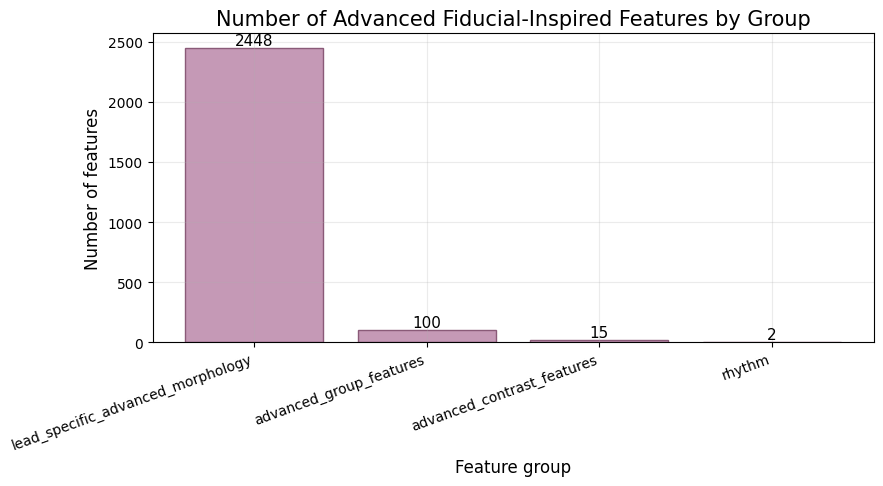

Saved figure: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\figures\notebook4B_advanced_feature_group_counts.png


In [54]:
adv_feature_cols = [
    col for col in advanced_features_clean_df.columns
    if "_adv_" in col
]

lead_specific_adv_cols = [
    col for col in adv_feature_cols
    if any(col.startswith(f"{lead}_adv_") for lead in LEAD_NAMES)
]

group_adv_cols = [
    col for col in adv_feature_cols
    if "_group_adv_" in col
]

contrast_adv_cols = [
    col for col in adv_feature_cols
    if col.startswith("contrast_")
]

rhythm_cols = [
    col for col in advanced_features_clean_df.columns
    if col.startswith("rhythm_")
]

feature_group_counts_df = pd.DataFrame([
    {
        "feature_group": "lead_specific_advanced_morphology",
        "n_features": len(lead_specific_adv_cols)
    },
    {
        "feature_group": "advanced_group_features",
        "n_features": len(group_adv_cols)
    },
    {
        "feature_group": "advanced_contrast_features",
        "n_features": len(contrast_adv_cols)
    },
    {
        "feature_group": "rhythm",
        "n_features": len(rhythm_cols)
    }
])

display(feature_group_counts_df)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    feature_group_counts_df["feature_group"],
    feature_group_counts_df["n_features"],
    color=PURPLE_MAIN,
    edgecolor=PURPLE_DARK
)

plt.title("Number of Advanced Fiducial-Inspired Features by Group")
plt.xlabel("Feature group")
plt.ylabel("Number of features")
plt.xticks(rotation=20, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        str(int(height)),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

fig_path = FIGURE_DIR / "notebook4B_advanced_feature_group_counts.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved figure:", fig_path)

In [56]:
advanced_features_clean_df.to_csv(
    advanced_features_path,
    index=False,
    encoding="utf-8-sig"
)

feature_metadata = {
    "notebook": "04B_advanced_fiducial_morphology_features",
    "description": "Advanced fiducial-inspired morphology features extracted around detected QRS peaks.",
    "important_note": (
        "These features are fiducial-inspired but not expert-annotated clinical fiducial points. "
     "Q, S, dominant QRS peak, ST, and T-wave regions are estimated using fixed windows around detected QRS peaks."
    ),
    "input_records_file": str(detection_file_path),
    "output_feature_file": str(advanced_features_path),
    "n_records": int(advanced_features_clean_df.shape[0]),
    "n_columns": int(advanced_features_clean_df.shape[1]),
    "n_lead_specific_advanced_features": int(len(lead_specific_adv_cols)),
    "n_group_advanced_features": int(len(group_adv_cols)),
    "n_contrast_advanced_features": int(len(contrast_adv_cols)),
    "n_rhythm_features": int(len(rhythm_cols)),
    "advanced_windows": ADVANCED_WINDOWS
}

with open(advanced_feature_metadata_path, "w", encoding="utf-8") as f:
    json.dump(feature_metadata, f, indent=4)

print("Saved advanced features to:", advanced_features_path)
print("Saved metadata to:", advanced_feature_metadata_path)

print("\nFeature metadata:")
print(json.dumps(feature_metadata, indent=4))

Saved advanced features to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\data\features\ptb_detection_advanced_fiducial_features.csv
Saved metadata to: d:\HUST\ET4248E - Học máy trong y tế\Final Project\results\tables\notebook4B_advanced_fiducial_feature_metadata.json

Feature metadata:
{
    "notebook": "04B_advanced_fiducial_morphology_features",
    "description": "Advanced fiducial-inspired morphology features extracted around detected QRS peaks.",
    "important_note": "These features are fiducial-inspired but not expert-annotated clinical fiducial points. Q, S, dominant QRS peak, ST, and T-wave regions are estimated using fixed windows around detected QRS peaks.",
    "input_records_file": "d:\\HUST\\ET4248E - H\u1ecdc m\u00e1y trong y t\u1ebf\\Final Project\\data\\processed\\ptb_detection_records.csv",
    "output_feature_file": "d:\\HUST\\ET4248E - H\u1ecdc m\u00e1y trong y t\u1ebf\\Final Project\\data\\features\\ptb_detection_advanced_fiducial_features.csv",
    "n_record